In [1]:
import sys
import os
from pathlib import Path
import warnings
import argparse
import json

warnings.filterwarnings("ignore")

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from transformers import CLIPProcessor, CLIPModel, AutoImageProcessor, AutoModel
from tqdm import tqdm

2025-11-25 19:19:37.324213: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-25 19:19:37.729080: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764069577.877142  446085 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764069577.919886  446085 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764069578.244135  446085 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
dataset_dict = {
    "ccmc": {
        "input": "../data/ccmc/images",
        "splits": ["ccmc_train", "ccmc_val", "ccmc_test"],
        "output": "../data/ccmc/features",
    },
    "coco2014": {
        "input": "../data/coco/coco2014",
        "splits": ["train2014", "val2014", "test2014"],
        "output": "../data/coco/coco2014",
    },
}

model_dict = {
    "clip_vit_base_patch32": {
        "type": "clip",
        "size": "base",
        "path": "../models/models--openai--clip-vit-base-patch32",
    },
    "clip_vit_large_patch14": {
        "type": "clip",
        "size": "large",
        "path": "../models/models--openai--clip-vit-large-patch14",
    },
    "dinov2_small": {"type": "dinov2", "size": "small", "path": "../models/dinov2-small"},
    "dinov2_base": {"type": "dinov2", "size": "base", "path": "../models/dinov2-base"},
    "dinov2_large": {"type": "dinov2", "size": "large", "path": "../models/dinov2-large"},
    "dinov2_giant": {"type": "dinov2", "size": "giant", "path": "../models/dinov2-giant"},
}

In [3]:
def load_model_and_processor(model_id):
    """加载所有配置的模型和处理器"""

    # 使用model_dict映射获取模型信息
    if model_id not in model_dict:
        raise ValueError(f"Unsupported model id: {model_id}")

    model_info = model_dict[model_id]
    model_type = model_info["type"]
    model_path = model_info["path"]

    device = "cuda" if torch.cuda.is_available() else "cpu"

    print(f"Loading {model_type} model '{model_id}' from {model_path}...")

    if model_type == "clip":
        model = CLIPModel.from_pretrained(model_path).to(device)
        processor = CLIPProcessor.from_pretrained(model_path, use_fast=True)
    elif model_type == "dinov2":
        model = AutoModel.from_pretrained(model_path).to(device)
        processor = AutoImageProcessor.from_pretrained(model_path, use_fast=True)
    else:
        raise ValueError(f"Unsupported model type: {model_type}")

    model.eval()
    return model, processor

In [4]:
# -------------------- 加载模型 --------------------
model = "clip_vit_large_patch14"
# model = "dinov2_large"
model_type = model_dict[model]["type"]

model, processor = load_model_and_processor(model)

Loading clip model 'clip_vit_large_patch14' from ../models/models--openai--clip-vit-large-patch14...


In [5]:
# -------------------- 加载并处理图像 --------------------
image_path = "../data/ccmc/images/ccmc_val/CCMC_val_000000038922.jpg"
# image_path = "../data/ccmc/images/ccmc_val/CCMC_val_000000017105.jpg"
# image_path = "../data/ccmc/images/ccmc_val/CCMC_val_000000006136.jpg"
# image_path = "../data/ccmc/images/ccmc_val/CCMC_val_000000020349.jpg"
# image_path = "../data/ccmc/images/ccmc_val/CCMC_val_000000002856.jpg"
# image_path = "../incivility.jpg"

image_pil = Image.open(image_path).convert("RGB")

# -------------------- 提取特征 --------------------
device = model.device
inputs = processor(images=image_pil, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

# -------------------- 提取特征 --------------------
with torch.no_grad():
    if model_type == "clip":
        outputs = model.vision_model(**inputs, output_hidden_states=True)
    elif model_type == "dinov2":
        outputs = model(**inputs, output_hidden_states=True)

hidden_states = outputs.hidden_states

In [6]:
layer12_feat = hidden_states[12]
layer24_feat = hidden_states[24]

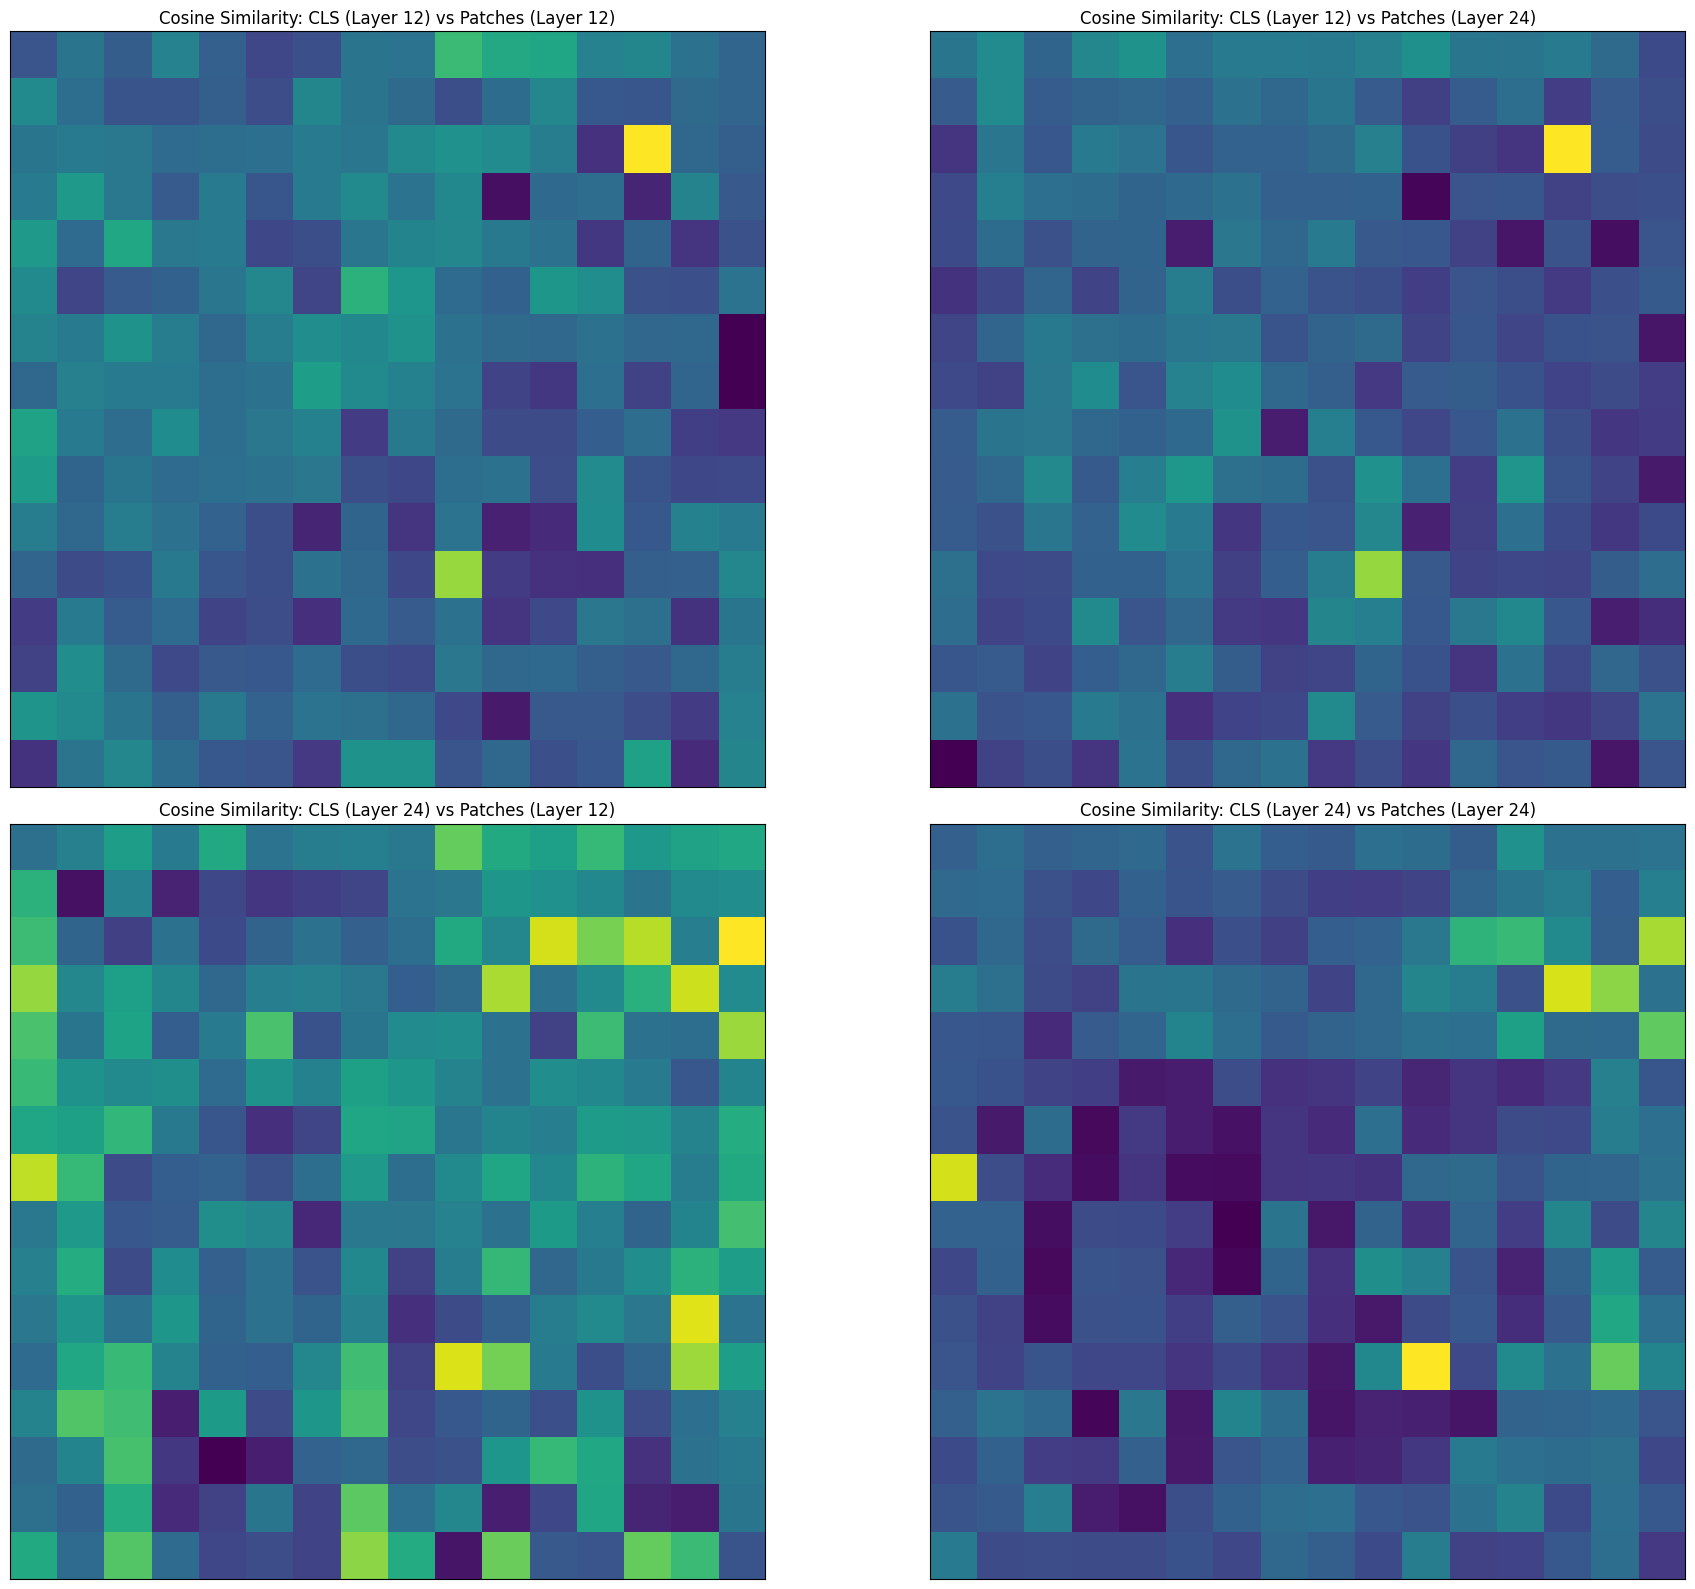

In [7]:
# 移除 batch 维度
feat12 = layer12_feat.squeeze(0)  # Shape: [257, 1024]
feat24 = layer24_feat.squeeze(0)  # Shape: [257, 1024]

# 分离 CLS token 和其他 patch tokens
cls_token_12 = feat12[0:1, :]      # CLS token from layer 12, shape: [1, 1024]
patches_12 = feat12[1:, :]         # Patch tokens from layer 12, shape: [256, 1024]
cls_token_24 = feat24[0:1, :]      # CLS token from layer 24, shape: [1, 1024]
patches_24 = feat24[1:, :]         # Patch tokens from layer 24, shape: [256, 1024]

# 对特征向量进行 L2 归一化
cls_token_12_normalized = F.normalize(cls_token_12, p=2, dim=1)
patches_12_normalized = F.normalize(patches_12, p=2, dim=1)
cls_token_24_normalized = F.normalize(cls_token_24, p=2, dim=1)
patches_24_normalized = F.normalize(patches_24, p=2, dim=1)

# cls_token_12_normalized = cls_token_12
# patches_12_normalized = patches_12
# cls_token_24_normalized = cls_token_24
# patches_24_normalized = patches_24


# 计算 CLS token 与 patch tokens 的余弦相似度
# 1. 第12层 CLS token 与第12层 patch tokens 的相似度
cls12_patches12_sim = torch.matmul(cls_token_12_normalized, patches_12_normalized.t())  # Shape: [1, 256]

# 2. 第12层 CLS token 与第24层 patch tokens 的相似度
cls12_patches24_sim = torch.matmul(cls_token_12_normalized, patches_24_normalized.t())  # Shape: [1, 256]

# 3. 第24层 CLS token 与第12层 patch tokens 的相似度
cls24_patches12_sim = torch.matmul(cls_token_24_normalized, patches_12_normalized.t())  # Shape: [1, 256]

# 4. 第24层 CLS token 与第24层 patch tokens 的相似度
cls24_patches24_sim = torch.matmul(cls_token_24_normalized, patches_24_normalized.t())  # Shape: [1, 256]

# 转换为 numpy 数组用于可视化
cls12_patches12_sim_np = cls12_patches12_sim.cpu().detach().numpy().flatten()  # Shape: [256]
cls12_patches24_sim_np = cls12_patches24_sim.cpu().detach().numpy().flatten()  # Shape: [256]
cls24_patches12_sim_np = cls24_patches12_sim.cpu().detach().numpy().flatten()  # Shape: [256]
cls24_patches24_sim_np = cls24_patches24_sim.cpu().detach().numpy().flatten()  # Shape: [256]

# 创建热力图可视化（不显示坐标轴和colorbar）
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 可视化第12层 CLS token 与第12层 patch tokens 的相似度
im1 = axes[0, 0].imshow(cls12_patches12_sim_np.reshape(16, 16), cmap='viridis')
axes[0, 0].set_title('Cosine Similarity: CLS (Layer 12) vs Patches (Layer 12)')
axes[0, 0].set_xticks([])
axes[0, 0].set_yticks([])

# 可视化第12层 CLS token 与第24层 patch tokens 的相似度
im2 = axes[0, 1].imshow(cls12_patches24_sim_np.reshape(16, 16), cmap='viridis')
axes[0, 1].set_title('Cosine Similarity: CLS (Layer 12) vs Patches (Layer 24)')
axes[0, 1].set_xticks([])
axes[0, 1].set_yticks([])

# 可视化第24层 CLS token 与第12层 patch tokens 的相似度
im3 = axes[1, 0].imshow(cls24_patches12_sim_np.reshape(16, 16), cmap='viridis')
axes[1, 0].set_title('Cosine Similarity: CLS (Layer 24) vs Patches (Layer 12)')
axes[1, 0].set_xticks([])
axes[1, 0].set_yticks([])

# 可视化第24层 CLS token 与第24层 patch tokens 的相似度
im4 = axes[1, 1].imshow(cls24_patches24_sim_np.reshape(16, 16), cmap='viridis')
axes[1, 1].set_title('Cosine Similarity: CLS (Layer 24) vs Patches (Layer 24)')
axes[1, 1].set_xticks([])
axes[1, 1].set_yticks([])

plt.tight_layout()
plt.show()

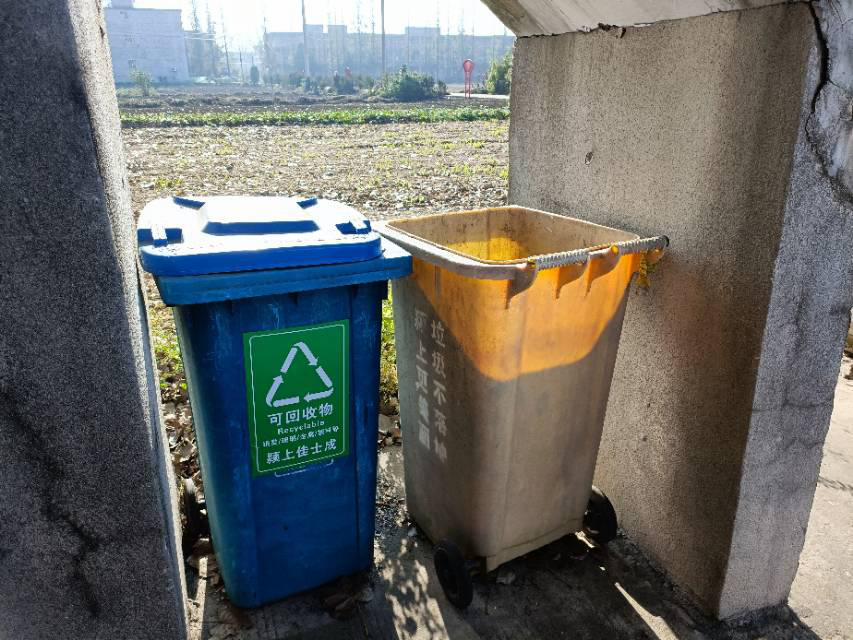

In [8]:
image_pil

## 导出

In [9]:
# 创建并保存四个独立的热力图（不显示坐标轴和colorbar）
# 1. 第12层 CLS token 与第12层 patch tokens 的相似度
plt.figure(figsize=(8, 8))
im1 = plt.imshow(cls12_patches12_sim_np.reshape(16, 16), cmap='viridis')
plt.xticks([])
plt.yticks([])
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)  # 调整子图参数以填满整个画布
plt.savefig('clip_cls12_patches12_similarity.png', bbox_inches='tight', pad_inches=0, dpi=600)
plt.close()

# 2. 第12层 CLS token 与第24层 patch tokens 的相似度
plt.figure(figsize=(8, 8))
im2 = plt.imshow(cls12_patches24_sim_np.reshape(16, 16), cmap='viridis')
plt.xticks([])
plt.yticks([])
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)  # 调整子图参数以填满整个画布
plt.savefig('clip_cls12_patches24_similarity.png', bbox_inches='tight', pad_inches=0, dpi=600)
plt.close()

# 3. 第24层 CLS token 与第12层 patch tokens 的相似度
plt.figure(figsize=(8, 8))
im3 = plt.imshow(cls24_patches12_sim_np.reshape(16, 16), cmap='viridis')
plt.xticks([])
plt.yticks([])
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)  # 调整子图参数以填满整个画布
plt.savefig('clip_cls24_patches12_similarity.png', bbox_inches='tight', pad_inches=0, dpi=600)
plt.close()

# 4. 第24层 CLS token 与第24层 patch tokens 的相似度
plt.figure(figsize=(8, 8))
im4 = plt.imshow(cls24_patches24_sim_np.reshape(16, 16), cmap='viridis')
plt.xticks([])
plt.yticks([])
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)  # 调整子图参数以填满整个画布
plt.savefig('clip_cls24_patches24_similarity.png', bbox_inches='tight', pad_inches=0, dpi=600)
plt.close()